In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# options of currency available

crypto_options = ['BTC','ETH','LTC'] # Bitcoing, Etherium, LiteCoin

In [4]:
crypto_choice  = input("Enter the currency : \n 1. BTC for Bitcoin \n 2. ETH for Etherium \n 3. LTC for Litecoin \n ")  

Enter the currency : 
 1. BTC for Bitcoin 
 2. ETH for Etherium 
 3. LTC for Litecoin 
 BTC


In [5]:
crypto_choice

'BTC'

In [12]:
# Bitcoin

data_path = 'bitcoin2018to2021.csv'
data_path

'bitcoin2018to2021.csv'

In [215]:
df = pd.read_csv('bitcoin2018to2021.csv',encoding="utf-8")

In [216]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018/1/1,14112.2002,14112.20020,13154.70020,13657.20020,13657.20020,1.029120e+10
1,2018/1/2,13625.0000,15444.59961,13163.59961,14982.09961,14982.09961,1.684660e+10
2,2018/1/3,14978.2002,15572.79981,14844.50000,15201.00000,15201.00000,1.687190e+10
3,2018/1/4,15270.7002,15739.70020,14522.20020,15599.20020,15599.20020,2.178320e+10
4,2018/1/5,15477.2002,17705.19922,15202.79981,17429.50000,17429.50000,2.384090e+10


In [217]:
# Preparing dataset for multivariate : technical indicator features
def moving_average(df, n):
    """Calculate the moving average for the given data.
    
    :param df: pandas.DataFrame
    :param n: 
    :return: pandas.DataFrame
    """
    MA = pd.Series(df['Close'].rolling(n, min_periods=n).mean(), name='MA_' + str(n))
    df = df.join(MA, how='left')
    return df

def exponential_moving_average(df, n):
    """
    
    :param df: pandas.DataFrame
    :param n: 
    :return: pandas.DataFrame
    """
    EMA = pd.Series(df['Close'].ewm(span=n, min_periods=n).mean(), name='EMA_' + str(n))
    df = df.join(EMA, how='left')
    return df

def momentum(df, n):
    """
    
    :param df: pandas.DataFrame 
    :param n: 
    :return: pandas.DataFrame
    """
    M = pd.Series(df['Close'].diff(n), name='Momentum_' + str(n))
    df = df.join(M, how='left')
    return df


def rate_of_change(df, n):
    """
    
    :param df: pandas.DataFrame
    :param n: 
    :return: pandas.DataFrame
    """
    M = df['Close'].diff(n - 1)
    N = df['Close'].shift(n - 1)
    ROC = pd.Series(M / N, name='ROC_' + str(n))
    df = df.join(ROC, how='left')
    return df


def average_true_range(df, n):
    """
    
    :param df: pandas.DataFrame
    :param n: 
    :return: pandas.DataFrame
    """
    i = 0
    TR_l = [0]
    while i < df.index[-1]:
        TR = max(df.loc[i + 1, 'High'], df.loc[i, 'Close']) - min(df.loc[i + 1, 'Low'], df.loc[i, 'Close'])
        TR_l.append(TR)
        i = i + 1
    TR_s = pd.Series(TR_l)
    ATR = pd.Series(TR_s.ewm(span=n, min_periods=n).mean(), name='ATR_' + str(n))
    df = df.join(ATR, how='left')
    return df


def bollinger_bands(df, n):
    """
    
    :param df: pandas.DataFrame
    :param n: 
    :return: pandas.DataFrame
    """
    MA = pd.Series(df['Close'].rolling(n, min_periods=n).mean())
    MSD = pd.Series(df['Close'].rolling(n, min_periods=n).std())
    b1 = 4 * MSD / MA
    B1 = pd.Series(b1, name='BollingerB_' + str(n))
    df = df.join(B1, how='left')
    b2 = (df['Close'] - MA + 2 * MSD) / (4 * MSD)
    B2 = pd.Series(b2, name='Bollinger%b_' + str(n))
    df = df.join(B2, how='left')
    return df


def ppsr(df):
    """Calculate Pivot Points, Supports and Resistances for given data
    
    :param df: pandas.DataFrame
    :return: pandas.DataFrame
    """
    PP = pd.Series((df['High'] + df['Low'] + df['Close']) / 3)
    R1 = pd.Series(2 * PP - df['Low'])
    S1 = pd.Series(2 * PP - df['High'])
    R2 = pd.Series(PP + df['High'] - df['Low'])
    S2 = pd.Series(PP - df['High'] + df['Low'])
    R3 = pd.Series(df['High'] + 2 * (PP - df['Low']))
    S3 = pd.Series(df['Low'] - 2 * (df['High'] - PP))
    psr = {'PP': PP, 'R1': R1, 'S1': S1, 'R2': R2, 'S2': S2, 'R3': R3, 'S3': S3}
    PSR = pd.DataFrame(psr)
    df = df.join(PSR, how='left')
    return df


def stochastic_oscillator_k(df):
    """Calculate stochastic oscillator %K for given data.
    
    :param df: pandas.DataFrame
    :return: pandas.DataFrame
    """
    SOk = pd.Series((df['Close'] - df['Low']) / (df['High'] - df['Low']), name='SO%k')
    df = df.join(SOk, how='left')
    return df


def stochastic_oscillator_d(df, n):
    """Calculate stochastic oscillator %D for given data.
    :param df: pandas.DataFrame
    :param n: 
    :return: pandas.DataFrame
    """
    SOk = pd.Series((df['Close'] - df['Low']) / (df['High'] - df['Low']), name='SO%k')
    SOd = pd.Series(SOk.ewm(span=n, min_periods=n).mean(), name='SO%d_' + str(n))
    df = df.join(SOd, how='left')
    return df


def trix(df, n):
    """Calculate TRIX for given data.
    
    :param df: pandas.DataFrame
    :param n: 
    :return: pandas.DataFrame
    """
    EX1 = df['Close'].ewm(span=n, min_periods=n).mean()
    EX2 = EX1.ewm(span=n, min_periods=n).mean()
    EX3 = EX2.ewm(span=n, min_periods=n).mean()
    i = 0
    ROC_l = [np.nan]
    while i + 1 <= df.index[-1]:
        ROC = (EX3[i + 1] - EX3[i]) / EX3[i]
        ROC_l.append(ROC)
        i = i + 1
    Trix = pd.Series(ROC_l, name='Trix_' + str(n))
    df = df.join(Trix, how='left')
    return df


def average_directional_movement_index(df, n, n_ADX):
    """Calculate the Average Directional Movement Index for given data.
    
    :param df: pandas.DataFrame
    :param n: 
    :param n_ADX: 
    :return: pandas.DataFrame
    """
    i = 0
    UpI = []
    DoI = []
    while i + 1 <= df.index[-1]:
        UpMove = df.loc[i + 1, 'High'] - df.loc[i, 'High']
        DoMove = df.loc[i, 'Low'] - df.loc[i + 1, 'Low']
        if UpMove > DoMove and UpMove > 0:
            UpD = UpMove
        else:
            UpD = 0
        UpI.append(UpD)
        if DoMove > UpMove and DoMove > 0:
            DoD = DoMove
        else:
            DoD = 0
        DoI.append(DoD)
        i = i + 1
    i = 0
    TR_l = [0]
    while i < df.index[-1]:
        TR = max(df.loc[i + 1, 'High'], df.loc[i, 'Close']) - min(df.loc[i + 1, 'Low'], df.loc[i, 'Close'])
        TR_l.append(TR)
        i = i + 1
    TR_s = pd.Series(TR_l)
    ATR = pd.Series(TR_s.ewm(span=n, min_periods=n).mean())
    UpI = pd.Series(UpI)
    DoI = pd.Series(DoI)
    PosDI = pd.Series(UpI.ewm(span=n, min_periods=n).mean() / ATR)
    NegDI = pd.Series(DoI.ewm(span=n, min_periods=n).mean() / ATR)
    ADX = pd.Series((abs(PosDI - NegDI) / (PosDI + NegDI)).ewm(span=n_ADX, min_periods=n_ADX).mean(),
                    name='ADX_' + str(n) + '_' + str(n_ADX))
    df = df.join(ADX, how='left')
    return df


def macd(df, n_fast, n_slow):
    """Calculate MACD, MACD Signal and MACD difference
    
    :param df: pandas.DataFrame
    :param n_fast: 
    :param n_slow: 
    :return: pandas.DataFrame
    """
    EMAfast = pd.Series(df['Close'].ewm(span=n_fast, min_periods=n_slow).mean())
    EMAslow = pd.Series(df['Close'].ewm(span=n_slow, min_periods=n_slow).mean())
    MACD = pd.Series(EMAfast - EMAslow, name='MACD_' + str(n_fast) + '_' + str(n_slow))
    MACDsign = pd.Series(MACD.ewm(span=9, min_periods=9).mean(), name='MACDsign_' + str(n_fast) + '_' + str(n_slow))
    MACDdiff = pd.Series(MACD - MACDsign, name='MACDdiff_' + str(n_fast) + '_' + str(n_slow))
    df = df.join(MACD, how='left')
    df = df.join(MACDsign, how='left')
    df = df.join(MACDdiff, how='left')
    return df


def mass_index(df):
    """Calculate the Mass Index for given data.
    
    :param df: pandas.DataFrame
    :return: pandas.DataFrame
    """
    Range = df['High'] - df['Low']
    EX1 = Range.ewm(span=9, min_periods=9).mean()
    EX2 = EX1.ewm(span=9, min_periods=9).mean()
    Mass = EX1 / EX2
    MassI = pd.Series(Mass.rolling(25).sum(), name='Mass Index')
    df = df.join(MassI, how='left')
    return df

In [218]:
df = moving_average(df, 10)
df = exponential_moving_average(df, 10)
df = momentum(df, 10)
df = rate_of_change(df, 10)
df = average_true_range(df, 10)
df = bollinger_bands(df, 10)
df = ppsr(df)
df = stochastic_oscillator_k(df)
df = stochastic_oscillator_d(df, 10)
df = trix(df, 10)
df = average_directional_movement_index(df, 10, 25)
df = macd(df, 10, 50)
df = mass_index(df)

In [219]:
df = df.replace([np.inf, -np.inf], np.nan)

df = df.fillna(df.mean())

In [220]:
dataset = df.drop(['Adj Close'],axis=1)
values = dataset.values
dataset.head(5)

,Date,Open,High,Low,Close,Volume,MA_10,EMA_10,Momentum_10,ROC_10,...,R3,S3,SO%k,SO%d_10,Trix_10,ADX_10_25,MACD_10_50,MACDsign_10_50,MACDdiff_10_50,Mass Index
0,2018/1/1,14112.2002,14112.20020,13154.70020,13657.20020,1.029120e+10,18313.254768,18311.597542,229.393304,0.014601,...,15085.533533,12213.033533,0.524804,0.541713,0.000983,0.438808,589.913012,603.91684,-9.160486,24.949914
1,2018/1/2,13625.0000,15444.59961,13163.59961,14982.09961,1.684660e+10,18313.254768,18311.597542,229.393304,0.014601,...,18177.599610,11334.599610,0.797238,0.541713,0.000983,0.438808,589.913012,603.91684,-9.160486,24.949914
2,2018/1/3,14978.2002,15572.79981,14844.50000,15201.00000,1.687190e+10,18313.254768,18311.597542,229.393304,0.014601,...,16295.999683,14111.100253,0.489496,0.541713,0.000983,0.438808,589.913012,603.91684,-9.160486,24.949914
3,2018/1/4,15270.7002,15739.70020,14522.20020,15599.20020,2.178320e+10,18313.254768,18311.597542,229.393304,0.014601,...,17269.366867,13616.866867,0.884600,0.541713,0.000983,0.438808,589.913012,603.91684,-9.160486,24.949914
4,2018/1/5,15477.2002,17705.19922,15202.79981,17429.50000,2.384090e+10,18313.254768,18311.597542,229.393304,0.014601,...,20857.932287,13350.734057,0.889826,0.541713,0.000983,0.438808,589.913012,603.91684,-9.160486,24.949914


In [221]:
dataset.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'MA_10', 'EMA_10',
       'Momentum_10', 'ROC_10', 'ATR_10', 'BollingerB_10', 'Bollinger%b_10',
       'PP', 'R1', 'S1', 'R2', 'S2', 'R3', 'S3', 'SO%k', 'SO%d_10', 'Trix_10',
       'ADX_10_25', 'MACD_10_50', 'MACDsign_10_50', 'MACDdiff_10_50',
       'Mass Index'],
      dtype='object')

In [222]:
y = dataset['Close']
X = dataset.drop(['Close'],axis=1)

In [223]:
X = X.join(y)

In [224]:
X

,Date,Open,High,Low,Volume,MA_10,EMA_10,Momentum_10,ROC_10,ATR_10,...,S3,SO%k,SO%d_10,Trix_10,ADX_10_25,MACD_10_50,MACDsign_10_50,MACDdiff_10_50,Mass Index,Close
0,2018/1/1,14112.20020,14112.20020,13154.70020,1.029120e+10,18313.254768,18311.597542,229.393304,0.014601,1030.386700,...,12213.033533,0.524804,0.541713,0.000983,0.438808,589.913012,603.916840,-9.160486,24.949914,13657.20020
1,2018/1/2,13625.00000,15444.59961,13163.59961,1.684660e+10,18313.254768,18311.597542,229.393304,0.014601,1030.386700,...,11334.599610,0.797238,0.541713,0.000983,0.438808,589.913012,603.916840,-9.160486,24.949914,14982.09961
2,2018/1/3,14978.20020,15572.79981,14844.50000,1.687190e+10,18313.254768,18311.597542,229.393304,0.014601,1030.386700,...,14111.100253,0.489496,0.541713,0.000983,0.438808,589.913012,603.916840,-9.160486,24.949914,15201.00000
3,2018/1/4,15270.70020,15739.70020,14522.20020,2.178320e+10,18313.254768,18311.597542,229.393304,0.014601,1030.386700,...,13616.866867,0.884600,0.541713,0.000983,0.438808,589.913012,603.916840,-9.160486,24.949914,15599.20020
4,2018/1/5,15477.20020,17705.19922,15202.79981,2.384090e+10,18313.254768,18311.597542,229.393304,0.014601,1030.386700,...,13350.734057,0.889826,0.541713,0.000983,0.438808,589.913012,603.916840,-9.160486,24.949914,17429.50000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1457,2021/12/28,50679.85938,50679.85938,47414.21094,3.343038e+10,49222.780079,49329.926094,740.078130,0.018880,2047.156147,...,43176.442707,0.053479,0.347072,-0.001154,0.354880,-2870.149540,-3616.967725,746.818185,23.705536,47588.85547
1458,2021/12/29,47623.87109,48119.74219,46201.49609,3.004923e+10,49196.549610,48805.341520,-262.304690,-0.009291,2023.717956,...,43805.977857,0.126790,0.307021,-0.001181,0.361811,-3169.033537,-3527.380887,358.347351,23.228066,46444.71094
1459,2021/12/30,46490.60547,47879.96484,46060.31250,2.668649e+10,49226.334376,48509.483971,297.847660,-0.035934,1986.615117,...,44379.317713,0.614300,0.362890,-0.001358,0.355518,-3276.802848,-3477.265280,200.462431,22.979517,47178.12500
1460,2021/12/31,47169.37109,48472.52734,45819.95313,3.697417e+10,48963.317579,48108.931487,-2630.167970,-0.047751,2107.698588,...,42607.515637,0.183404,0.330256,-0.001702,0.349709,-3462.459587,-3474.304141,11.844554,22.859553,46306.44531


In [225]:
hist = X.set_index('Date')
hist.index = pd.to_datetime(hist.index)
target_col = 'Close'
hist.head(5)

,Open,High,Low,Volume,MA_10,EMA_10,Momentum_10,ROC_10,ATR_10,BollingerB_10,...,S3,SO%k,SO%d_10,Trix_10,ADX_10_25,MACD_10_50,MACDsign_10_50,MACDdiff_10_50,Mass Index,Close
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,14112.2002,14112.20020,13154.70020,1.029120e+10,18313.254768,18311.597542,229.393304,0.014601,1030.3867,0.180928,...,12213.033533,0.524804,0.541713,0.000983,0.438808,589.913012,603.91684,-9.160486,24.949914,13657.20020
2018-01-02,13625.0000,15444.59961,13163.59961,1.684660e+10,18313.254768,18311.597542,229.393304,0.014601,1030.3867,0.180928,...,11334.599610,0.797238,0.541713,0.000983,0.438808,589.913012,603.91684,-9.160486,24.949914,14982.09961
2018-01-03,14978.2002,15572.79981,14844.50000,1.687190e+10,18313.254768,18311.597542,229.393304,0.014601,1030.3867,0.180928,...,14111.100253,0.489496,0.541713,0.000983,0.438808,589.913012,603.91684,-9.160486,24.949914,15201.00000
2018-01-04,15270.7002,15739.70020,14522.20020,2.178320e+10,18313.254768,18311.597542,229.393304,0.014601,1030.3867,0.180928,...,13616.866867,0.884600,0.541713,0.000983,0.438808,589.913012,603.91684,-9.160486,24.949914,15599.20020
2018-01-05,15477.2002,17705.19922,15202.79981,2.384090e+10,18313.254768,18311.597542,229.393304,0.014601,1030.3867,0.180928,...,13350.734057,0.889826,0.541713,0.000983,0.438808,589.913012,603.91684,-9.160486,24.949914,17429.50000


In [251]:
X.to_csv('Daily_more_features.csv',index = False, header=True) 

In [226]:
def train_test_split(X, test_size=0.15):
    split_row = len(X) - int(test_size * len(X))
    train_data = X.iloc[:split_row]
    test_data = X.iloc[split_row:]
    return train_data, test_data

In [227]:
train, test = train_test_split(hist, test_size=0.15)

In [228]:
def line_plot(line1, line2, label1=None, label2=None, title='', lw=2):
    fig, ax = plt.subplots(1, figsize=(13, 7))
    ax.plot(line1, label=label1, linewidth=lw)
    ax.plot(line2, label=label2, linewidth=lw)
    ax.set_ylabel('price [USD]', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.legend(loc='best', fontsize=16);


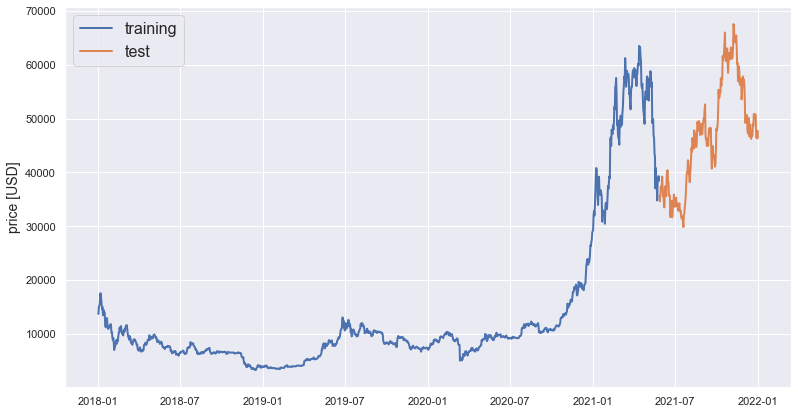

In [229]:
from keras.models import Sequential
from keras.layers import Activation, Dense, Dropout, LSTM
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import mean_absolute_error

line_plot(train[target_col], test[target_col], 'training', 'test', title='')

In [230]:
X.iloc[0]

Date                 2018/1/1
Open                  14112.2
High                  14112.2
Low                   13154.7
Volume            1.02912e+10
MA_10                 18313.3
EMA_10                18311.6
Momentum_10           229.393
ROC_10              0.0146012
ATR_10                1030.39
BollingerB_10        0.180928
Bollinger%b_10       0.524905
PP                    13641.4
R1                      14128
S1                    13170.5
R2                    14598.9
S2                    12683.9
R3                    15085.5
S3                      12213
SO%k                 0.524804
SO%d_10              0.541713
Trix_10           0.000983208
ADX_10_25            0.438808
MACD_10_50            589.913
MACDsign_10_50        603.917
MACDdiff_10_50       -9.16049
Mass Index            24.9499
Close                 13657.2
Name: 0, dtype: object

In [237]:
def normalise_zero_base(X):
    return X / X.iloc[0] - 1

def normalise_min_max(X):
    return (X - X.min()) / (data.max() - X.min())

In [238]:
def extract_window_data(X, window_len=5, zero_base=True):
    window_data = []
    for idx in range(len(X) - window_len):
        tmp = X[idx: (idx + window_len)].copy()
        if zero_base:
            tmp = normalise_zero_base(tmp)
        window_data.append(tmp.values)
    return np.array(window_data)

In [239]:
def prepare_data(X, target_col, window_len=10, zero_base=True, test_size=0.15):
    train_data, test_data = train_test_split(X, test_size=test_size)
    X_train = extract_window_data(train_data, window_len, zero_base)
    X_test = extract_window_data(test_data, window_len, zero_base)
    y_train = train_data[target_col][window_len:].values
    y_test = test_data[target_col][window_len:].values
    if zero_base:
        y_train = y_train / train_data[target_col][:-window_len].values - 1
        y_test = y_test / test_data[target_col][:-window_len].values - 1

    return train_data, test_data, X_train, X_test, y_train, y_test

In [240]:
def build_lstm_model(input_data, output_size, neurons=100, activ_func='linear',
                     dropout=0.2, loss='mse', optimizer='adam'):
    model = Sequential()
    model.add(LSTM(neurons, input_shape=(input_data.shape[1], input_data.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(units=output_size))
    model.add(Activation(activ_func))

    model.compile(loss=loss, optimizer=optimizer)
    return model

In [249]:
np.random.seed(42)
window_len = 5
test_size = 0.15
zero_base = True
lstm_neurons = 100
epochs = 20
batch_size = 32
loss = 'mse'
dropout = 0.01
optimizer = 'adam'

In [247]:
train, test, X_train, X_test, y_train, y_test = prepare_data(
    hist, target_col, window_len=window_len, zero_base=zero_base, test_size=test_size)

In [248]:
model = build_lstm_model(
    X_train, output_size=1, neurons=lstm_neurons, dropout=dropout, loss=loss,
    optimizer=optimizer)
history = model.fit(
    X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=batch_size, verbose=1, shuffle=True)

Train on 1238 samples, validate on 214 samples
Epoch 1/20
1238/1238 [==============================] - 3s 3ms/step - loss: nan - val_loss: nan
Epoch 2/20
1238/1238 [==============================] - 1s 728us/step - loss: nan - val_loss: nan
Epoch 3/20
1238/1238 [==============================] - 1s 750us/step - loss: nan - val_loss: nan
Epoch 4/20
1238/1238 [==============================] - 1s 850us/step - loss: nan - val_loss: nan
Epoch 5/20
1238/1238 [==============================] - 1s 1ms/step - loss: nan - val_loss: nan
Epoch 6/20
1238/1238 [==============================] - 1s 968us/step - loss: nan - val_loss: nan
Epoch 7/20
1238/1238 [==============================] - 1s 956us/step - loss: nan - val_loss: nan
Epoch 8/20
1238/1238 [==============================] - 2s 1ms/step - loss: nan - val_loss: nan
Epoch 9/20
1238/1238 [==============================] - 2s 1ms/step - loss: nan - val_loss: nan
Epoch 10/20
1238/1238 [==============================] - 1s 1ms/step - loss: na

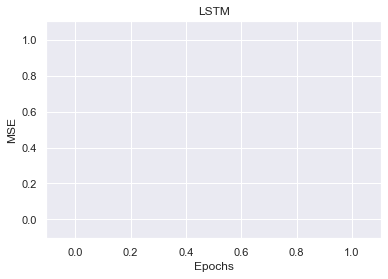

In [244]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],'r',linewidth=2, label='Train loss')
plt.plot(history.history['val_loss'], 'g',linewidth=2, label='Validation loss')
plt.title('LSTM')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.show()

In [245]:
targets = test[target_col][window_len:]
preds = model.predict(X_test).squeeze()
MAE=mean_absolute_error(preds, y_test)
MAE

ValueError: Input contains NaN, infinity or a value too large for dtype('float32').

In [137]:
# frame as supervised learning
reframed = series_to_supervised(scaled, n_hours, 1)


In [138]:
print(reframed.shape)

AttributeError: 'NoneType' object has no attribute 'shape'

In [141]:
# split into train and test sets
values = reframed.values
n_train_hours = 1455
train = values[:int(0.9*n_train_hours), :]
test = values[int(0.9*n_train_hours):, :]
# split into input and outputs
n_obs = n_hours * n_features
train_X, train_y = train[:, :n_obs], train[:, -n_features]
test_X, test_y = test[:, :n_obs], test[:, -n_features]
print(train_X.shape, len(train_X), train_y.shape)

AttributeError: 'NoneType' object has no attribute 'values'